# Final Project: EMG Grip Strength Classification

**BioRobotics**

---

## Learning Objectives

By the end of this lab, you will be able to:

1. **Load and structure EMG data** from the Myo armband
2. **Apply signal processing techniques** including filtering, rectification, and envelope extraction
3. **Extract meaningful features** from EMG signals (time and frequency domain)
4. **Perform exploratory data analysis** to understand gesture patterns
5. **Build and evaluate classifiers** using LDA, QDA, and K-means
6. **Interpret results** using confusion matrices and cross-validation

---

## How to Use This Notebook

This notebook is organized in two phases:

**Phase 1 (Parts 1-3):** Learn the fundamentals using a **single sample recording**
- Understand data format
- Apply signal processing
- Extract features

**Phase 2 (Parts 4-6):** Apply to your **complete dataset**
- Load all trials
- Exploratory analysis
- Classification

**Code guidance:**
- **Completed code** demonstrates techniques
- **`# TODO` sections** require your implementation
- **Questions (Q1-Q10)** must be answered in the designated cells

---

## Part 0: Setup and Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
from pathlib import Path
import os
import glob
import warnings
import time
import datetime
warnings.filterwarnings('ignore')

# Signal processing
import scipy.signal as signal
from scipy import stats
from scipy.fft import fft, fftfreq

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

# Set random seed for reproducibility
np.random.seed(42)

# Constants
SAMPLE_RATE = 200  # Hz (Myo EMG sample rate)
N_CHANNELS = 8     # Myo has 8 EMG channels

print("✓ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All imports successful!
NumPy version: 2.3.5
Pandas version: 2.3.3


## Loading EMG File

In [2]:
def load_emg_file(filepath):
    """
    Load an EMG CSV file with metadata header.
    
    Calculates the EFFECTIVE sample rate from recorded timestamps to handle
    hardware variation (Myo typically runs at ~196Hz, not exactly 200Hz).
    Creates a uniform time vector that preserves correct total duration.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the CSV file
    
    Returns
    -------
    data : pd.DataFrame
        EMG data with uniform 'time' column based on effective sample rate
    metadata : dict
        Includes 'effective_sample_rate' and 'nominal_sample_rate'
    """
    metadata = {}
    header_lines = 0
    
    # Read header lines starting with #
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                header_lines += 1
                if ':' in line:
                    key, value = line[1:].split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    try:
                        value = int(value)
                    except ValueError:
                        try:
                            value = float(value)
                        except ValueError:
                            pass
                    metadata[key] = value
            else:
                break
    
    # Read the data
    data = pd.read_csv(filepath, skiprows=header_lines)
    
    # Calculate EFFECTIVE sample rate from this recording
    n_samples = len(data)
    if 'timestamp' in data.columns and n_samples > 1:
        total_duration = data['timestamp'].iloc[-1] - data['timestamp'].iloc[0]
        effective_rate = (n_samples - 1) / total_duration
        
        # Create uniform time vector at the effective rate
        # This preserves correct total duration while giving uniform sampling
        data['time'] = np.arange(n_samples) / effective_rate
        
        # Store both rates in metadata
        metadata['effective_sample_rate'] = effective_rate
        metadata['nominal_sample_rate'] = 200  # What Myo claims
        metadata['recorded_duration'] = total_duration
        
        # Keep original timestamps for reference
        data['timestamp_raw'] = data['timestamp']
    else:
        # Fallback if no timestamps
        data['time'] = np.arange(n_samples) / 200
        metadata['effective_sample_rate'] = 200
        metadata['nominal_sample_rate'] = 200
    
    return data, metadata

print("✓ load_emg_file() function defined (with effective sample rate correction)")


✓ load_emg_file() function defined (with effective sample rate correction)


## Filters

In [3]:
def bandpass_filter(data, lowcut, highcut, sample_rate, order=4):
    """
    Apply a Butterworth bandpass filter.
    
    Parameters
    ----------
    data : np.ndarray
        Input signal
    lowcut : float
        Low cutoff frequency (Hz)
    highcut : float
        High cutoff frequency (Hz)
    sample_rate : float
        Sampling frequency (Hz)
    order : int
        Filter order (default: 4)
    
    Returns
    -------
    filtered : np.ndarray
        Filtered signal
    """
    # TODO: Calculate the Nyquist frequency (half of sample rate)

    nyquist = 0.5 * sample_rate
    
    
    # TODO: Normalize cutoff frequencies to Nyquist (0 to 1 range)

    low = lowcut / nyquist
    high = highcut / nyquist
    
    
    # TODO: Design the Butterworth bandpass filter
    # Use: signal.butter(order, [low, high], btype='band')

    b, a = signal.butter(order, [low, high], btype='band')
    
    # TODO: Apply zero-phase filtering
    # Use: signal.filtfilt(b, a, data)
    
    filtered = signal.filtfilt(b, a, data)
    
    return filtered

print("✓ bandpass_filter() defined")

✓ bandpass_filter() defined


In [4]:
def notch_filter(data, notch_freq, sample_rate, Q=30):
    """
    Apply a notch filter to remove a specific frequency.
    
    Parameters
    ----------
    data : np.ndarray
        Input signal
    notch_freq : float
        Frequency to remove (Hz)
    sample_rate : float
        Sampling frequency (Hz)
    Q : float
        Quality factor - higher = narrower notch (default: 30)
    
    Returns
    -------
    filtered : np.ndarray
        Filtered signal
    """
    # TODO: Design the notch filter
    # Use: signal.iirnotch(notch_freq, Q, sample_rate)

    b, a = signal.iirnotch(notch_freq, Q, sample_rate)
    
    # TODO: Apply zero-phase filtering

    filtered = signal.filtfilt(b, a, data)

    return filtered

print("✓ notch_filter() defined")

✓ notch_filter() defined


In [5]:
def compute_envelope(data, sample_rate, cutoff_freq=5):
    """
    Compute EMG envelope using rectification and low-pass filtering.
    
    Parameters
    ----------
    data : np.ndarray
        Filtered EMG signal
    sample_rate : float
        Sampling frequency
    cutoff_freq : float
        Low-pass cutoff for smoothing (default: 5 Hz)
    
    Returns
    -------
    envelope : np.ndarray
        Smoothed envelope
    """
    # Step 1: Rectify (absolute value)
    rectified = np.abs(data)
    
    # Step 2: Low-pass filter to smooth
    nyquist = sample_rate / 2
    normalized_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(4, normalized_cutoff, btype='low')
    envelope = signal.filtfilt(b, a, rectified)
    
    return envelope

# # Compute envelope for channel 1
# rectified = np.abs(filtered)
# envelope = compute_envelope(filtered, SAMPLE_RATE, cutoff_freq=5)

print("✓ Envelope computed")

✓ Envelope computed


## Feature Extraction

In [6]:
def compute_mav(data):
    """
    Mean Absolute Value: average of |x|
    
    MAV = (1/N) * sum(|x_i|)
    """
    # TODO: Implement using np.abs() and np.mean()
    mav = np.mean(np.abs(data))
    return mav


def compute_rms(data):
    """
    Root Mean Square: square root of average squared value
    
    RMS = sqrt((1/N) * sum(x_i^2))
    """
    # TODO: Implement using np.sqrt() and np.mean()
    rms = np.sqrt(np.mean(data)**2)
    return rms


def compute_wl(data):
    """
    Waveform Length: sum of absolute differences
    
    WL = sum(|x_{i+1} - x_i|)
    """
    # TODO: Implement using np.diff(), np.abs(), np.sum()
    wl = np.sum(np.abs(np.diff(data)))
    return wl


# # Test on filtered signal
# print("Testing your implementations on Channel 1:")
# print(f"  MAV = {compute_mav(filtered)}")
# print(f"  RMS = {compute_rms(filtered)}")
# print(f"  WL  = {compute_wl(filtered)}")

In [7]:
# We provide Zero Crossings and Slope Sign Changes

def compute_zc(data, threshold=0):
    """
    Zero Crossings: count of times signal crosses zero
    """
    signs = np.sign(data)
    sign_changes = np.diff(signs)
    crossings = np.abs(sign_changes) == 2
    
    if threshold > 0:
        amplitude_check = np.abs(np.diff(data)) >= threshold
        crossings = crossings & amplitude_check
    
    return np.sum(crossings)


def compute_ssc(data, threshold=0):
    """
    Slope Sign Changes: count of local peaks and valleys
    """
    diff1 = data[1:-1] - data[:-2]
    diff2 = data[1:-1] - data[2:]
    ssc = np.sum((diff1 * diff2) > threshold)
    return ssc


# print(f"  ZC  = {compute_zc(filtered)}")
# print(f"  SSC = {compute_ssc(filtered)}")

In [8]:
def compute_frequency_features(data, sample_rate):
    """
    Extract frequency-domain features from EMG signal.
    
    Returns: mean_freq, median_freq, total_power
    """
    # Compute power spectral density
    freqs, psd = signal.welch(data, fs=sample_rate, nperseg=min(256, len(data)))
    
    # Total power
    total_power = np.sum(psd)
    
    # Mean frequency (centroid)
    mean_freq = np.sum(freqs * psd) / total_power if total_power > 0 else 0
    
    # Median frequency (divides power in half)
    cumulative = np.cumsum(psd)
    median_idx = np.searchsorted(cumulative, total_power / 2)
    median_freq = freqs[min(median_idx, len(freqs)-1)]
    
    return {
        'mean_freq': mean_freq,
        'median_freq': median_freq,
        'total_power': total_power
    }

# freq_feats = compute_frequency_features(filtered, SAMPLE_RATE)
# print("Frequency features:")
# for name, value in freq_feats.items():
#     print(f"  {name}: {value:.4f}")

In [9]:
def extract_channel_features(data, sample_rate):
    """
    Extract all features from a single EMG channel.
    
    Applies filtering first, then extracts features.
    """
    # Filter the signal
    filtered = bandpass_filter(data, 20, 95, sample_rate)
    filtered = notch_filter(filtered, 60, sample_rate)
    
    # Time-domain features
    features = {
        'mav': compute_mav(filtered),
        'rms': compute_rms(filtered),
        'wl': compute_wl(filtered),
        'zc': compute_zc(filtered),
        'ssc': compute_ssc(filtered)
    }
    
    # Frequency-domain features
    freq_feats = compute_frequency_features(filtered, sample_rate)
    features.update(freq_feats)
    
    return features


def extract_all_features(data_df, sample_rate):
    """
    Extract features from all 8 EMG channels.
    
    Returns dict with keys like 'ch1_mav', 'ch2_rms', etc.
    """
    all_features = {}
    
    for ch in range(1, N_CHANNELS + 1):
        col = f'emg_{ch}'
        if col in data_df.columns:
            ch_features = extract_channel_features(data_df[col].values, sample_rate)
            for feat_name, feat_value in ch_features.items():
                all_features[f'ch{ch}_{feat_name}'] = feat_value
    
    return all_features


# # Extract features from sample recording
# sample_features = extract_all_features(sample_df, SAMPLE_RATE)

# print(f"Extracted {len(sample_features)} features from sample recording:")
# print("-" * 50)
# for i, (name, value) in enumerate(sample_features.items()):
#     if value is not None:
#         print(f"  {name}: {value:.4f}")
#     else:
#         print(f"  {name}: None (implement the function above)")
#     if i >= 15:
#         print(f"  ... and {len(sample_features) - 16} more features")
#         break

## Epoch Grabbing

In [10]:
def create_sliding_windows(data, window_size=0.5, step_size=0.25, time_col='timestamp'):
    """
    Slices a continuous data trial into overlapping windows based on timestamps.
    
    Parameters:
    - data: Pandas DataFrame containing the trial data
    - window_size: Length of the window (in the same units as time_col)
    - step_size: How far to slide forward for the next window
    - time_col: The exact name of the column containing timestamp data
    
    Returns: A list of DataFrames, where each DataFrame is one window.
    """
    windows = []
    
    # Identify the start and end of the recording
    start_time = data[time_col].min()
    end_time = data[time_col].max()
    
    current_start = start_time
    
    # Keep sliding until the end of a window would exceed the data's end time
    while (current_start + window_size) <= end_time:
        current_end = current_start + window_size
        
        # Filter rows where the timestamp falls within the current window
        mask = (data[time_col] >= current_start) & (data[time_col] < current_end)
        window_df = data[mask].copy() 
        
        # Add to our list if data exists
        if not window_df.empty:
            windows.append(window_df)
            
        # Slide forward by the step size
        current_start += step_size
        
    return windows

In [11]:
DATA_DIR = '../recordings/'  # Change this path!

GESTURES = ['baseline', 'soft', 'medium', 'hard']

def load_all_trials(data_dir):
    """
    Load all EMG trial files from nested participant directories.
    
    Returns: dict with gesture names as keys, list of (data, metadata) as values
    """
    # Pre-initialize the dictionary with empty lists for each gesture
    all_data = {gesture: [] for gesture in GESTURES}

    # 1. Iterate through everything in the main data directory (Participants)
    for participant_dir in os.listdir(data_dir):
        participant_path = os.path.join(data_dir, participant_dir)
        
        # Skip if it's a file (like a .DS_Store or README) instead of a folder
        if not os.path.isdir(participant_path):
            continue
            
        # 2. Find all EMG CSV files within each participant's gesture folders
        for gesture in GESTURES:
            gesture_folder = os.path.join(participant_path, gesture)
            
            # Skip if this specific participant doesn't have this gesture folder
            if not os.path.isdir(gesture_folder):
                continue

            pattern = os.path.join(gesture_folder, '*_emg_*.csv')
            files = glob.glob(pattern)

            if not files:
                continue

            print(f"Found {len(files)} EMG files for participant '{participant_dir}' in '{gesture}'")
            
            for filepath in sorted(files):
                # Load each 30s file
                data, metadata = load_emg_file(filepath)
                
                # Slice the 30s data into a list of 5s windows
                trial_windows = create_sliding_windows(
                    data, 
                    window_size=0.5, 
                    step_size=0.25, 
                    time_col='timestamp' # Make sure this matches your CSV exactly
                )
                
                # Append EACH window to the master dictionary alongside the metadata
                for window in trial_windows:
                    all_data[gesture].append((window, metadata))

    return all_data

# Execute the loading function
all_trials = load_all_trials(DATA_DIR)

# Summarize loaded data
print("\n" + "="*60)
print("LOADED STUDENT DATA")
print("="*60)
total_trials = 0

for gesture in GESTURES:
    n_trials = len(all_trials.get(gesture, []))
    total_trials += n_trials
    status = "✓" if n_trials > 0 else "✗"
    print(f"  {status} {gesture}: {n_trials} trials")
    
# Count how many gestures actually have data
active_gestures = len([g for g in all_trials if len(all_trials[g]) > 0])
print(f"\n✓ Loaded {total_trials} total recordings across {active_gestures} gestures")

Found 2 EMG files for participant 'P1' in 'baseline'
Found 2 EMG files for participant 'P1' in 'soft'
Found 2 EMG files for participant 'P1' in 'medium'
Found 2 EMG files for participant 'P1' in 'hard'
Found 2 EMG files for participant 'P10' in 'baseline'
Found 2 EMG files for participant 'P10' in 'soft'
Found 2 EMG files for participant 'P10' in 'medium'
Found 2 EMG files for participant 'P10' in 'hard'
Found 2 EMG files for participant 'P11' in 'baseline'
Found 2 EMG files for participant 'P11' in 'soft'
Found 2 EMG files for participant 'P11' in 'medium'
Found 2 EMG files for participant 'P11' in 'hard'
Found 2 EMG files for participant 'P12' in 'baseline'
Found 2 EMG files for participant 'P12' in 'soft'
Found 2 EMG files for participant 'P12' in 'medium'
Found 2 EMG files for participant 'P12' in 'hard'
Found 2 EMG files for participant 'P2' in 'baseline'
Found 2 EMG files for participant 'P2' in 'soft'
Found 2 EMG files for participant 'P2' in 'medium'
Found 2 EMG files for parti

In [12]:
feature_rows = []

print("Extracting features...")
for gesture, trials in all_trials.items():
    for data_df, metadata in trials:
        # Extract features
        features = extract_all_features(data_df, SAMPLE_RATE)
        
        # Add metadata
        features['gesture'] = gesture
        features['participant'] = metadata.get('participant_id', 'unknown')
        features['trial'] = metadata.get('trial_number', 0)
        
        feature_rows.append(features)

# Create DataFrame
features_df = pd.DataFrame(feature_rows)

print(f"\n✓ Feature matrix shape: {features_df.shape}")
print(f"  Samples: {len(features_df)}")
print(f"  Features per sample: {len([c for c in features_df.columns if c not in ['gesture', 'participant', 'trial']])}")

# Show first few rows
features_df.head()

Extracting features...

✓ Feature matrix shape: (11629, 67)
  Samples: 11629
  Features per sample: 64


,ch1_mav,ch1_rms,ch1_wl,ch1_zc,ch1_ssc,ch1_mean_freq,ch1_median_freq,ch1_total_power,ch2_mav,ch2_rms,...,ch8_rms,ch8_wl,ch8_zc,ch8_ssc,ch8_mean_freq,ch8_median_freq,ch8_total_power,gesture,participant,trial
0,1.452863,0.053401,180.677486,47,49,59.378489,63.157895,1.694521,2.988643,0.067399,...,0.002692,273.909070,41,50,64.912679,65.789474,8.548428,baseline,P1,1
1,1.503095,0.008517,210.063195,51,56,65.184281,75.609756,1.981364,2.502113,0.065865,...,0.069431,347.396212,45,55,54.583781,53.658537,1.464928,baseline,P1,1
2,1.762950,0.035372,257.467051,49,62,67.513158,72.093023,2.611700,3.233689,0.100758,...,0.062110,502.458673,45,59,70.464324,76.744186,20.277847,baseline,P1,1
3,1.739623,0.002258,244.642755,53,60,56.038605,53.488372,2.285207,3.803825,0.095768,...,0.004582,398.395951,47,58,64.502604,72.093023,16.269375,baseline,P1,1
4,1.266327,0.020001,179.913890,51,56,61.941219,64.444444,1.303645,3.592734,0.004412,...,0.062359,163.938070,49,56,58.122584,57.777778,0.862590,baseline,P1,1


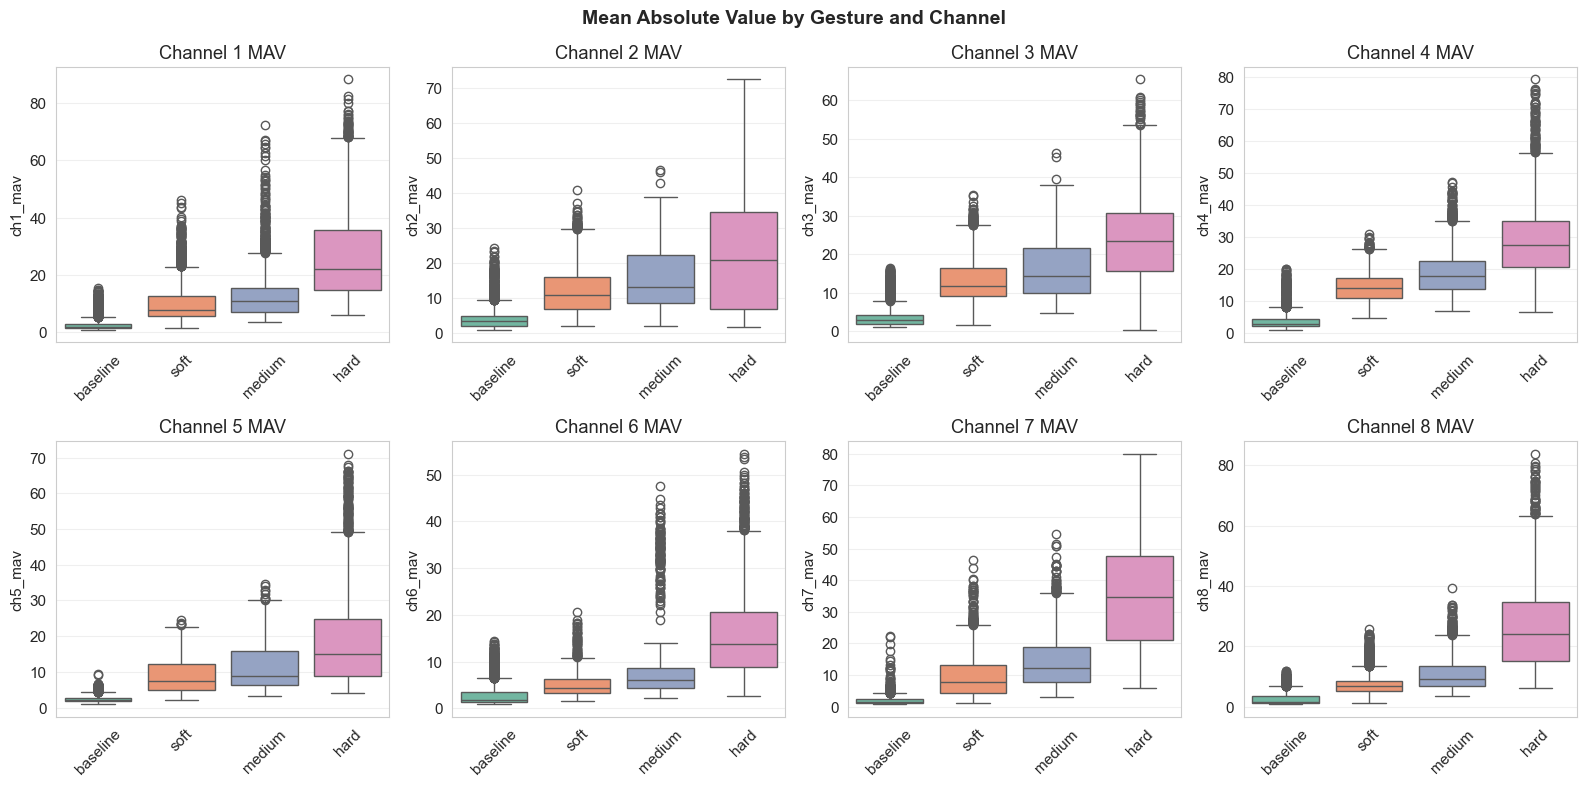

In [13]:
# Box plot of MAV for each channel by gesture
mav_cols = [f'ch{i}_mav' for i in range(1, 9) if f'ch{i}_mav' in features_df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(mav_cols):
    if features_df[col].notna().any():
        sns.boxplot(data=features_df, x='gesture', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Channel {i+1} MAV')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].text(0.5, 0.5, 'Implement MAV', ha='center', va='center', fontsize=12)
        axes[i].set_title(f'Channel {i+1} MAV')

plt.suptitle('Mean Absolute Value by Gesture and Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Select feature columns (exclude metadata)
feature_cols = [col for col in features_df.columns 
                if col not in ['gesture', 'participant', 'trial']
                and features_df[col].notna().all()]

print(f"Using {len(feature_cols)} features for classification")

# Create feature matrix and labels
X = features_df[feature_cols].values
y = features_df['gesture'].values
P = features_df['participant'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"X shape: {X.shape}")
print(f"Classes: {label_encoder.classes_}")

Using 64 features for classification
X shape: (11629, 64)
Classes: ['baseline' 'hard' 'medium' 'soft']


## LDA

In [15]:
# Initialize the cross-validator
logo = LeaveOneGroupOut()

fold = 1
accuracies = []

# .split() automatically figures out how many unique groups (participants) you have
# and loops that many times.
for train_index, test_index in logo.split(X, y, P):
    
    # Slice the arrays using the indices sklearn provided
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Grab the participant ID being tested in this fold (for logging)
    test_subject = P[test_index][0] 
    
    print(f"--- Fold {fold}: Testing on {test_subject} ---")
    print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_lda = lda.predict(X_test_scaled)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred_lda)
    print(f"Accuracy: {accuracy:.2%}")
    accuracies.append(accuracy)
    print()
    
    fold += 1

# Average the accuracies across all folds
print("------------------------------------------------")
print(f"\nFinal LDA LOSO Accuracy: {np.mean(accuracies):.4f}")

--- Fold 1: Testing on P1 ---
Training samples: 10667 | Testing samples: 962
Accuracy: 75.88%

--- Fold 2: Testing on P10 ---
Training samples: 10669 | Testing samples: 960
Accuracy: 73.65%

--- Fold 3: Testing on P11 ---
Training samples: 10667 | Testing samples: 962
Accuracy: 74.43%

--- Fold 4: Testing on P12 ---
Training samples: 10664 | Testing samples: 965
Accuracy: 84.56%

--- Fold 5: Testing on P2 ---
Training samples: 10660 | Testing samples: 969
Accuracy: 70.59%

--- Fold 6: Testing on P3 ---
Training samples: 10653 | Testing samples: 976
Accuracy: 73.67%

--- Fold 7: Testing on P4 ---
Training samples: 10666 | Testing samples: 963
Accuracy: 54.41%

--- Fold 8: Testing on P5 ---
Training samples: 10662 | Testing samples: 967
Accuracy: 71.25%

--- Fold 9: Testing on P6 ---
Training samples: 10618 | Testing samples: 1011
Accuracy: 82.69%

--- Fold 10: Testing on P7 ---
Training samples: 10662 | Testing samples: 967
Accuracy: 79.63%

--- Fold 11: Testing on P8 ---
Training sampl

=== FOLD 1 ===
Train: ['P3' 'P11' 'P10' 'P9' 'P2' 'P5' 'P12' 'P4'] | Val: ['P1' 'P6'] | Test: ['P8' 'P7']
Validation Acc: 80.99% | Test Acc: 73.54%

=== FOLD 2 ===
Train: ['P10' 'P6' 'P7' 'P3' 'P11' 'P1' 'P4' 'P9'] | Val: ['P8' 'P2'] | Test: ['P12' 'P5']
Validation Acc: 66.17% | Test Acc: 75.52%

=== FOLD 3 ===
Train: ['P5' 'P7' 'P8' 'P12' 'P11' 'P6' 'P1' 'P9'] | Val: ['P4' 'P2'] | Test: ['P3' 'P10']
Validation Acc: 61.23% | Test Acc: 66.17%

=== FOLD 4 ===
Train: ['P1' 'P12' 'P5' 'P9' 'P11' 'P2' 'P8' 'P4'] | Val: ['P7' 'P3'] | Test: ['P6' 'P10']
Validation Acc: 74.32% | Test Acc: 77.17%

=== FOLD 5 ===
Train: ['P4' 'P9' 'P1' 'P2' 'P8' 'P10' 'P11' 'P3'] | Val: ['P7' 'P5'] | Test: ['P6' 'P12']
Validation Acc: 74.72% | Test Acc: 81.22%

=== FOLD 6 ===
Train: ['P3' 'P11' 'P12' 'P5' 'P6' 'P7' 'P2' 'P1'] | Val: ['P9' 'P4'] | Test: ['P8' 'P10']
Validation Acc: 70.04% | Test Acc: 57.59%

=== FOLD 7 ===
Train: ['P1' 'P5' 'P2' 'P6' 'P10' 'P11' 'P4' 'P7'] | Val: ['P12' 'P3'] | Test: ['P9' 'P8']


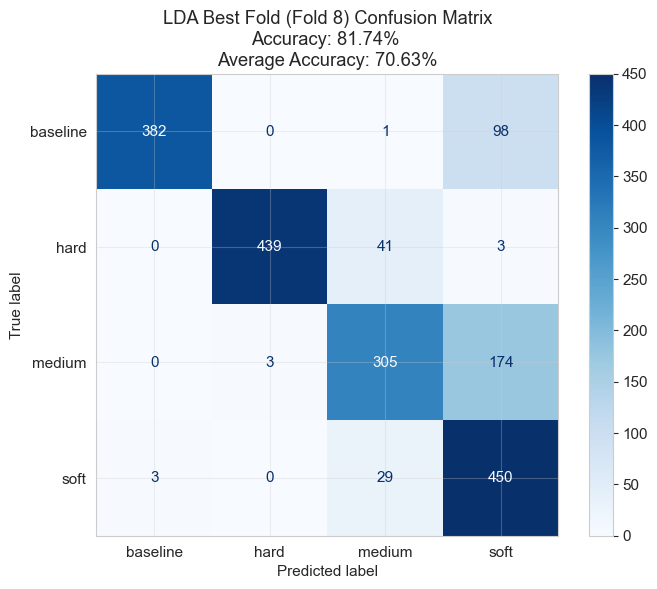

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Get unique participants
unique_participants = np.unique(P)

# Prepare lists to hold our scores
val_accuracies = []
test_accuracies = []

# --- Variables to catch the best performing fold ---
best_test_acc = 0.0
best_y_test = None
best_y_pred = None
best_fold = 0

# Define how many random splits you want to do
num_iterations = 10 

for fold in range(1, num_iterations + 1):
    
    # 2. SHUFFLE THE PARTICIPANTS EVERY LOOP
    np.random.shuffle(unique_participants)

    # 3. Pick the new random groups for this specific loop
    test_subs = unique_participants[:2]       
    val_subs = unique_participants[2:4]       
    train_subs = unique_participants[4:12]    

    print(f"=== FOLD {fold} ===")
    print(f"Train: {train_subs} | Val: {val_subs} | Test: {test_subs}")

    # 4. Create masks
    train_mask = np.isin(P, train_subs)
    val_mask = np.isin(P, val_subs)
    test_mask = np.isin(P, test_subs)

    # 5. Slice the data
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    # 6. Scale the data (Fit ONLY on training!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 7. Train the LDA model
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # 8. Evaluate Validation and Testing
    y_pred_val = lda.predict(X_val_scaled)
    y_pred_test = lda.predict(X_test_scaled)
    
    val_acc = accuracy_score(y_val, y_pred_val)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Save the scores
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    print(f"Validation Acc: {val_acc:.2%} | Test Acc: {test_acc:.2%}\n")
    
    # --- Check if this is the best fold so far ---
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold = fold
        # Copy the arrays so they aren't overwritten when the loop restarts
        best_y_test = y_test.copy()
        best_y_pred = y_pred_test.copy()

# 9. Print the final averaged results!
print("------------------------------------------------")
print(f"AVERAGE VALIDATION ACCURACY: {np.mean(val_accuracies):.2%}")
print(f"AVERAGE TEST ACCURACY:       {np.mean(test_accuracies):.2%}")
print(f"BEST TEST ACCURACY (Fold {best_fold}): {best_test_acc:.2%}")

# --- Plot the Confusion Matrix for the best fold ---
print("\nGenerating Confusion Matrix for the best test fold...")

# Get the unique class labels (e.g., 'soft', 'hard', 'baseline')
classes = np.unique(best_y_test)

# Calculate the matrix
cm = confusion_matrix(best_y_test, best_y_pred, labels=classes)

# Create the display plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot it using a blue color map
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"LDA Best Fold (Fold {best_fold}) Confusion Matrix\nAccuracy: {best_test_acc:.2%} \nAverage Accuracy: {np.mean(test_accuracies):.2%}")
plt.show()

## QDA

=== FOLD 1 ===
Train: ['P2' 'P1' 'P10' 'P12' 'P5' 'P9' 'P4' 'P6'] | Val: ['P8' 'P11'] | Test: ['P7' 'P3']
Validation Acc: 59.03% | Test Acc: 73.55%

=== FOLD 2 ===
Train: ['P4' 'P9' 'P1' 'P10' 'P2' 'P6' 'P7' 'P8'] | Val: ['P3' 'P5'] | Test: ['P12' 'P11']
Validation Acc: 49.25% | Test Acc: 62.95%

=== FOLD 3 ===
Train: ['P5' 'P12' 'P10' 'P8' 'P3' 'P2' 'P7' 'P1'] | Val: ['P11' 'P9'] | Test: ['P6' 'P4']
Validation Acc: 70.65% | Test Acc: 58.76%

=== FOLD 4 ===
Train: ['P2' 'P12' 'P8' 'P11' 'P7' 'P9' 'P1' 'P10'] | Val: ['P5' 'P4'] | Test: ['P3' 'P6']
Validation Acc: 59.33% | Test Acc: 64.62%

=== FOLD 5 ===
Train: ['P6' 'P5' 'P11' 'P9' 'P4' 'P12' 'P2' 'P7'] | Val: ['P3' 'P8'] | Test: ['P1' 'P10']
Validation Acc: 61.19% | Test Acc: 70.81%

=== FOLD 6 ===
Train: ['P3' 'P2' 'P6' 'P8' 'P12' 'P4' 'P7' 'P1'] | Val: ['P10' 'P11'] | Test: ['P5' 'P9']
Validation Acc: 67.43% | Test Acc: 70.36%

=== FOLD 7 ===
Train: ['P8' 'P11' 'P9' 'P10' 'P5' 'P3' 'P12' 'P7'] | Val: ['P1' 'P6'] | Test: ['P4' 'P2']


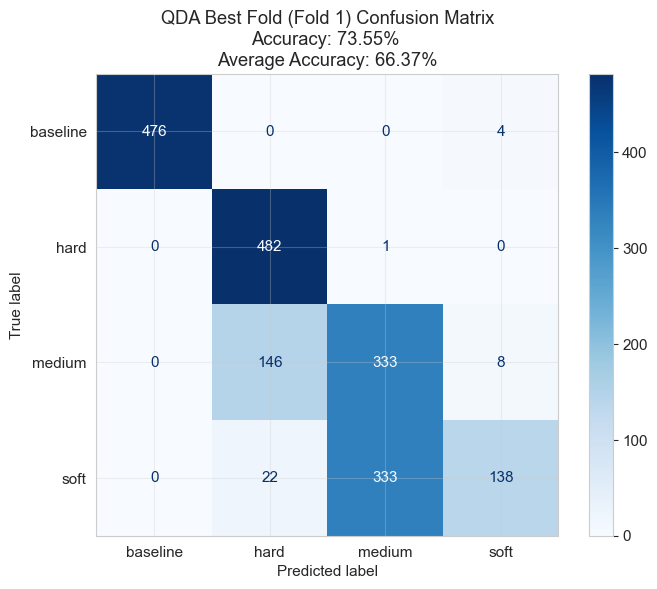

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Get unique participants
unique_participants = np.unique(P)

# Prepare lists to hold our scores
val_accuracies = []
test_accuracies = []

# --- Variables to catch the best performing fold ---
best_test_acc = 0.0
best_y_test = None
best_y_pred = None
best_fold = 0

# Define how many random splits you want to do
num_iterations = 10 

for fold in range(1, num_iterations + 1):
    
    # 2. SHUFFLE THE PARTICIPANTS EVERY LOOP
    np.random.shuffle(unique_participants)

    # 3. Pick the new random groups for this specific loop
    test_subs = unique_participants[:2]       
    val_subs = unique_participants[2:4]       
    train_subs = unique_participants[4:12]    

    print(f"=== FOLD {fold} ===")
    print(f"Train: {train_subs} | Val: {val_subs} | Test: {test_subs}")

    # 4. Create masks
    train_mask = np.isin(P, train_subs)
    val_mask = np.isin(P, val_subs)
    test_mask = np.isin(P, test_subs)

    # 5. Slice the data
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    # 6. Scale the data (Fit ONLY on training!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 7. Train the LDA model
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_train_scaled, y_train)

    # 8. Evaluate Validation and Testing
    y_pred_val = qda.predict(X_val_scaled)
    y_pred_test = qda.predict(X_test_scaled)
    
    val_acc = accuracy_score(y_val, y_pred_val)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Save the scores
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    print(f"Validation Acc: {val_acc:.2%} | Test Acc: {test_acc:.2%}\n")
    
    # --- Check if this is the best fold so far ---
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold = fold
        # Copy the arrays so they aren't overwritten when the loop restarts
        best_y_test = y_test.copy()
        best_y_pred = y_pred_test.copy()

# 9. Print the final averaged results!
print("------------------------------------------------")
print(f"AVERAGE VALIDATION ACCURACY: {np.mean(val_accuracies):.2%}")
print(f"AVERAGE TEST ACCURACY:       {np.mean(test_accuracies):.2%}")
print(f"BEST TEST ACCURACY (Fold {best_fold}): {best_test_acc:.2%}")

# --- Plot the Confusion Matrix for the best fold ---
print("\nGenerating Confusion Matrix for the best test fold...")

# Get the unique class labels (e.g., 'soft', 'hard', 'baseline')
classes = np.unique(best_y_test)

# Calculate the matrix
cm = confusion_matrix(best_y_test, best_y_pred, labels=classes)

# Create the display plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot it using a blue color map
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"QDA Best Fold (Fold {best_fold}) Confusion Matrix\nAccuracy: {best_test_acc:.2%} \nAverage Accuracy: {np.mean(test_accuracies):.2%}")
plt.show()

## KNN

=== FOLD 1 ===
Train: ['P11' 'P4' 'P9' 'P10' 'P12' 'P2' 'P5' 'P3'] | Val: ['P1' 'P7'] | Test: ['P8' 'P6']
Validation Acc: 73.61% | Test Acc: 58.03%

=== FOLD 2 ===
Train: ['P9' 'P12' 'P10' 'P7' 'P1' 'P4' 'P5' 'P3'] | Val: ['P6' 'P2'] | Test: ['P11' 'P8']
Validation Acc: 68.38% | Test Acc: 56.49%

=== FOLD 3 ===
Train: ['P4' 'P8' 'P7' 'P11' 'P5' 'P10' 'P2' 'P6'] | Val: ['P9' 'P3'] | Test: ['P12' 'P1']
Validation Acc: 80.76% | Test Acc: 74.36%

=== FOLD 4 ===
Train: ['P12' 'P6' 'P3' 'P2' 'P9' 'P10' 'P7' 'P1'] | Val: ['P4' 'P11'] | Test: ['P5' 'P8']
Validation Acc: 64.26% | Test Acc: 62.71%

=== FOLD 5 ===
Train: ['P6' 'P4' 'P2' 'P1' 'P3' 'P7' 'P12' 'P5'] | Val: ['P10' 'P11'] | Test: ['P9' 'P8']
Validation Acc: 64.20% | Test Acc: 68.19%

=== FOLD 6 ===
Train: ['P3' 'P10' 'P11' 'P7' 'P9' 'P5' 'P4' 'P1'] | Val: ['P8' 'P2'] | Test: ['P6' 'P12']
Validation Acc: 61.05% | Test Acc: 70.60%

=== FOLD 7 ===
Train: ['P10' 'P12' 'P3' 'P6' 'P4' 'P9' 'P8' 'P2'] | Val: ['P1' 'P11'] | Test: ['P5' 'P7']


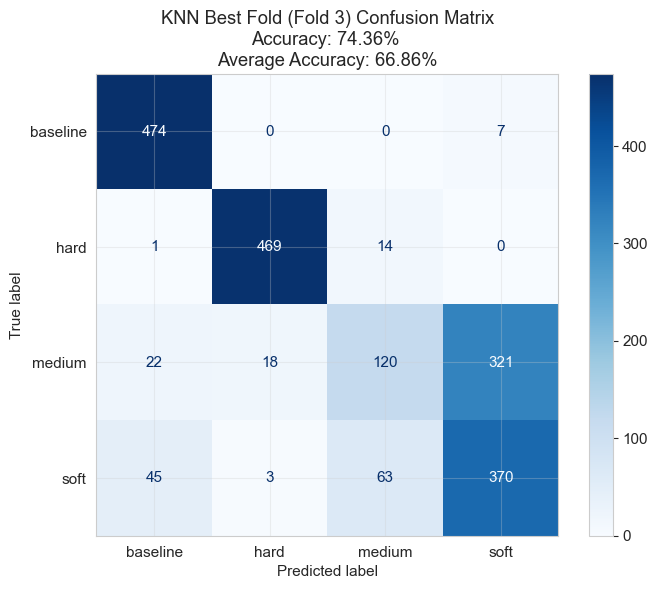

In [18]:
# 1. Get unique participants
unique_participants = np.unique(P)

# Prepare lists to hold our scores
val_accuracies = []
test_accuracies = []

# --- Variables to catch the best performing fold ---
best_test_acc = 0.0
best_y_test = None
best_y_pred = None
best_fold = 0

# Define how many random splits you want to do
num_iterations = 10 

for fold in range(1, num_iterations + 1):
    
    # 2. SHUFFLE THE PARTICIPANTS EVERY LOOP
    np.random.shuffle(unique_participants)

    # 3. Pick the new random groups for this specific loop
    test_subs = unique_participants[:2]       
    val_subs = unique_participants[2:4]       
    train_subs = unique_participants[4:12]    

    print(f"=== FOLD {fold} ===")
    print(f"Train: {train_subs} | Val: {val_subs} | Test: {test_subs}")

    # 4. Create masks
    train_mask = np.isin(P, train_subs)
    val_mask = np.isin(P, val_subs)
    test_mask = np.isin(P, test_subs)

    # 5. Slice the data
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    # 6. Scale the data (Fit ONLY on training!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 7. Train the LDA model
    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train_scaled, y_train)

    # 8. Evaluate Validation and Testing
    y_pred_val = knn.predict(X_val_scaled)
    y_pred_test = knn.predict(X_test_scaled)
    
    val_acc = accuracy_score(y_val, y_pred_val)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Save the scores
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    print(f"Validation Acc: {val_acc:.2%} | Test Acc: {test_acc:.2%}\n")
    
    # --- Check if this is the best fold so far ---
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold = fold
        # Copy the arrays so they aren't overwritten when the loop restarts
        best_y_test = y_test.copy()
        best_y_pred = y_pred_test.copy()

# 9. Print the final averaged results!
print("------------------------------------------------")
print(f"AVERAGE VALIDATION ACCURACY: {np.mean(val_accuracies):.2%}")
print(f"AVERAGE TEST ACCURACY:       {np.mean(test_accuracies):.2%}")
print(f"BEST TEST ACCURACY (Fold {best_fold}): {best_test_acc:.2%}")

# --- Plot the Confusion Matrix for the best fold ---
print("\nGenerating Confusion Matrix for the best test fold...")

# Get the unique class labels (e.g., 'soft', 'hard', 'baseline')
classes = np.unique(best_y_test)

# Calculate the matrix
cm = confusion_matrix(best_y_test, best_y_pred, labels=classes)

# Create the display plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot it using a blue color map
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"KNN Best Fold (Fold {best_fold}) Confusion Matrix\nAccuracy: {best_test_acc:.2%} \nAverage Accuracy: {np.mean(test_accuracies):.2%}")
plt.show()

## SVM

=== FOLD 1 ===
Train: ['P3' 'P8' 'P6' 'P5' 'P1' 'P9' 'P12' 'P11'] | Val: ['P4' 'P10'] | Test: ['P7' 'P2']
Validation Acc: 63.44% | Test Acc: 73.71%

=== FOLD 2 ===
Train: ['P6' 'P7' 'P5' 'P11' 'P1' 'P4' 'P8' 'P3'] | Val: ['P10' 'P9'] | Test: ['P12' 'P2']
Validation Acc: 82.22% | Test Acc: 79.47%

=== FOLD 3 ===
Train: ['P11' 'P2' 'P10' 'P3' 'P5' 'P6' 'P9' 'P12'] | Val: ['P1' 'P7'] | Test: ['P4' 'P8']
Validation Acc: 80.40% | Test Acc: 58.90%

=== FOLD 4 ===
Train: ['P5' 'P2' 'P10' 'P8' 'P12' 'P3' 'P1' 'P6'] | Val: ['P7' 'P9'] | Test: ['P4' 'P11']
Validation Acc: 85.75% | Test Acc: 63.17%

=== FOLD 5 ===
Train: ['P5' 'P7' 'P12' 'P1' 'P8' 'P4' 'P3' 'P11'] | Val: ['P2' 'P6'] | Test: ['P10' 'P9']
Validation Acc: 78.64% | Test Acc: 82.01%

=== FOLD 6 ===
Train: ['P10' 'P3' 'P6' 'P5' 'P1' 'P8' 'P9' 'P2'] | Val: ['P4' 'P12'] | Test: ['P11' 'P7']
Validation Acc: 70.02% | Test Acc: 71.38%

=== FOLD 7 ===
Train: ['P3' 'P7' 'P12' 'P1' 'P6' 'P4' 'P5' 'P11'] | Val: ['P8' 'P9'] | Test: ['P10' 'P2']


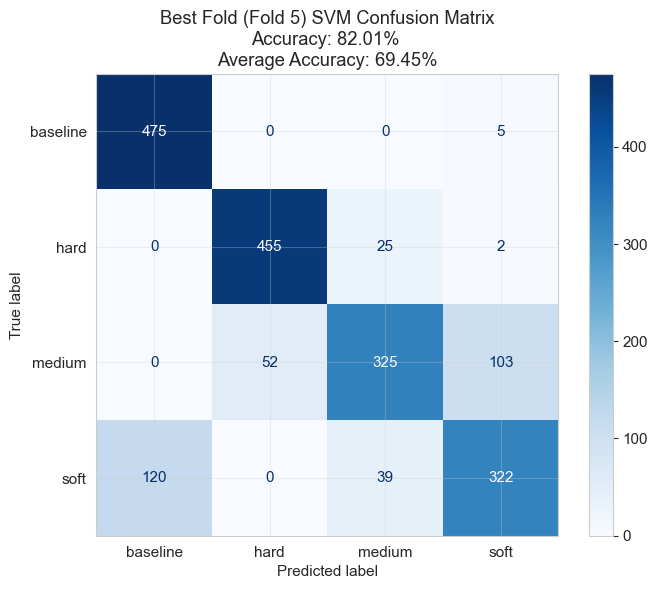

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Get unique participants
unique_participants = np.unique(P)

# Prepare lists to hold our scores
val_accuracies = []
test_accuracies = []

# --- NEW: Variables to catch the best performing fold ---
best_test_acc = 0.0
best_y_test = None
best_y_pred = None
best_fold = 0

# Define how many random splits you want to do
num_iterations = 10 

for fold in range(1, num_iterations + 1):
    
    # 2. SHUFFLE THE PARTICIPANTS EVERY LOOP
    np.random.shuffle(unique_participants)

    # 3. Pick the new random groups for this specific loop
    test_subs = unique_participants[:2]       
    val_subs = unique_participants[2:4]       
    train_subs = unique_participants[4:12]    

    print(f"=== FOLD {fold} ===")
    print(f"Train: {train_subs} | Val: {val_subs} | Test: {test_subs}")

    # 4. Create masks
    train_mask = np.isin(P, train_subs)
    val_mask = np.isin(P, val_subs)
    test_mask = np.isin(P, test_subs)

    # 5. Slice the data
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    # 6. Scale the data (Fit ONLY on training!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 7. Train the model
    model = SVC(kernel='rbf', C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)

    # 8. Evaluate Validation and Testing
    y_pred_val = model.predict(X_val_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    val_acc = accuracy_score(y_val, y_pred_val)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Save the scores
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    print(f"Validation Acc: {val_acc:.2%} | Test Acc: {test_acc:.2%}\n")
    
    # --- NEW: Check if this is the best fold so far ---
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold = fold
        # Copy the arrays so they aren't overwritten when the loop restarts
        best_y_test = y_test.copy()
        best_y_pred = y_pred_test.copy()

# 9. Print the final averaged results!
print("------------------------------------------------")
print(f"AVERAGE VALIDATION ACCURACY: {np.mean(val_accuracies):.2%}")
print(f"AVERAGE TEST ACCURACY:       {np.mean(test_accuracies):.2%}")
print(f"BEST TEST ACCURACY (Fold {best_fold}): {best_test_acc:.2%}")

# --- NEW: Plot the Confusion Matrix for the best fold ---
print("\nGenerating Confusion Matrix for the best test fold...")

# Get the unique class labels (e.g., 'soft', 'hard', 'baseline')
classes = np.unique(best_y_test)

# Calculate the matrix
cm = confusion_matrix(best_y_test, best_y_pred, labels=classes)

# Create the display plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot it using a blue color map
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"Best Fold (Fold {best_fold}) SVM Confusion Matrix\nAccuracy: {best_test_acc:.2%} \nAverage Accuracy: {np.mean(test_accuracies):.2%}")
plt.show()

In [22]:
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# ==========================================
# 1. LOAD YOUR DATA HERE
# ==========================================
# Make sure your X (features) and y (labels) arrays are loaded into memory.
# X should be an array of shape (total_samples, total_features)
# y should be an array of shape (total_samples,)
#
# e.g., X = np.load('my_X_data.npy') 
#       y = np.load('my_y_data.npy')

print("Step 1: Scaling all available data...")
# 2. Fit the scaler on ALL data and save it immediately
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X)

# Save the scaler so your real-time script can process live data identically
joblib.dump(scaler, 'dar2379_emg_scaler.pkl')
print("  -> Saved 'emg_scaler.pkl'\n")

# ==========================================
# 3. INITIALIZE ALL MODELS
# ==========================================
# We store them in a dictionary so we can easily loop through them.
# Feel free to update the hyperparameters (like K or C) to whatever 
# settings gave you the best Validation Accuracy in your earlier tests!
models = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(n_neighbors=5),  
    'SVM': SVC(kernel='rbf', C=1.0, random_state=42) 
}

# ==========================================
# 4. TRAIN AND SAVE EACH MODEL
# ==========================================
print("Step 2: Training and generating .pkl files for all models...")

for model_name, model_instance in models.items():
    print(f"  -> Training {model_name}...")
    
    # Train on 100% of the scaled data
    model_instance.fit(X_all_scaled, y)
    
    # Generate a dynamic filename (e.g., 'emg_model_lda.pkl')
    filename = f"dar2379_emg_model_{model_name.lower()}.pkl"
    
    # Save the model to your hard drive
    joblib.dump(model_instance, filename)
    print(f"     Successfully saved '{filename}'")

Step 1: Scaling all available data...
  -> Saved 'emg_scaler.pkl'

Step 2: Training and generating .pkl files for all models...
  -> Training LDA...
     Successfully saved 'dar2379_emg_model_lda.pkl'
  -> Training QDA...
     Successfully saved 'dar2379_emg_model_qda.pkl'
  -> Training KNN...
     Successfully saved 'dar2379_emg_model_knn.pkl'
  -> Training SVM...
     Successfully saved 'dar2379_emg_model_svm.pkl'
